In [4]:
%pip install matplotlib pandas seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   -------


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Set display options
pd.set_option('display.max_columns', None)

In [6]:
# Load cleaned dataset
df = pd.read_parquet('../data/processed/clean_yellow_2025-01.parquet')

# Ensure temporal features are derived
if 'pickup_hour' not in df.columns:
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
if 'pickup_dayofw' not in df.columns:
    df['pickup_dayofw'] = df['tpep_pickup_datetime'].dt.dayofweek
if 'duration_mins' not in df.columns:
    df['duration_mins'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60

# Define Target (y) and Features (X)
target = 'fare_amount'
feature_cols = [
    'trip_distance',
    'duration_mins',
    'pickup_hour',
    'pickup_dayofw',
    'passenger_count',
    'payment_type',
    'PULocationID',
    'DOLocationID',
]

X = df[feature_cols].copy()
y = df[target].copy()

# Handle any remaining missing values in features
X = X.fillna(0)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (2664530, 8)
Test shape: (666133, 8)


In [8]:
# 1. Baseline Model (Predicts the mean)
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

# 2. Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_lr = model.predict(X_test)


# Helper function to evaluate models
def evaluate_model(y_true, y_pred, name='Model'):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return pd.DataFrame(
        {'MAE ($)': [mae], 'RMSE ($)': [rmse], 'R² Score': [r2]}, index=[name]
    )


# Compare results
results = pd.concat(
    [
        evaluate_model(y_test, y_pred_base, 'Baseline (Mean)'),
        evaluate_model(y_test, y_pred_lr, 'Linear Regression'),
    ]
)

display(results.round(3))

,MAE ($),RMSE ($),R² Score
Baseline (Mean),10.631,16.737,-0.000
Linear Regression,9.369,15.767,0.112


In [9]:
coef_df = pd.DataFrame(
    {'Feature': feature_cols, 'Coefficient': model.coef_}
).sort_values(by='Coefficient', ascending=False)

display(coef_df.round(4))

,Feature,Coefficient
5,payment_type,2.9522
1,duration_mins,0.1932
4,passenger_count,0.0684
0,trip_distance,0.0002
7,DOLocationID,-0.0280
6,PULocationID,-0.0285
2,pickup_hour,-0.0429
3,pickup_dayofw,-0.3472


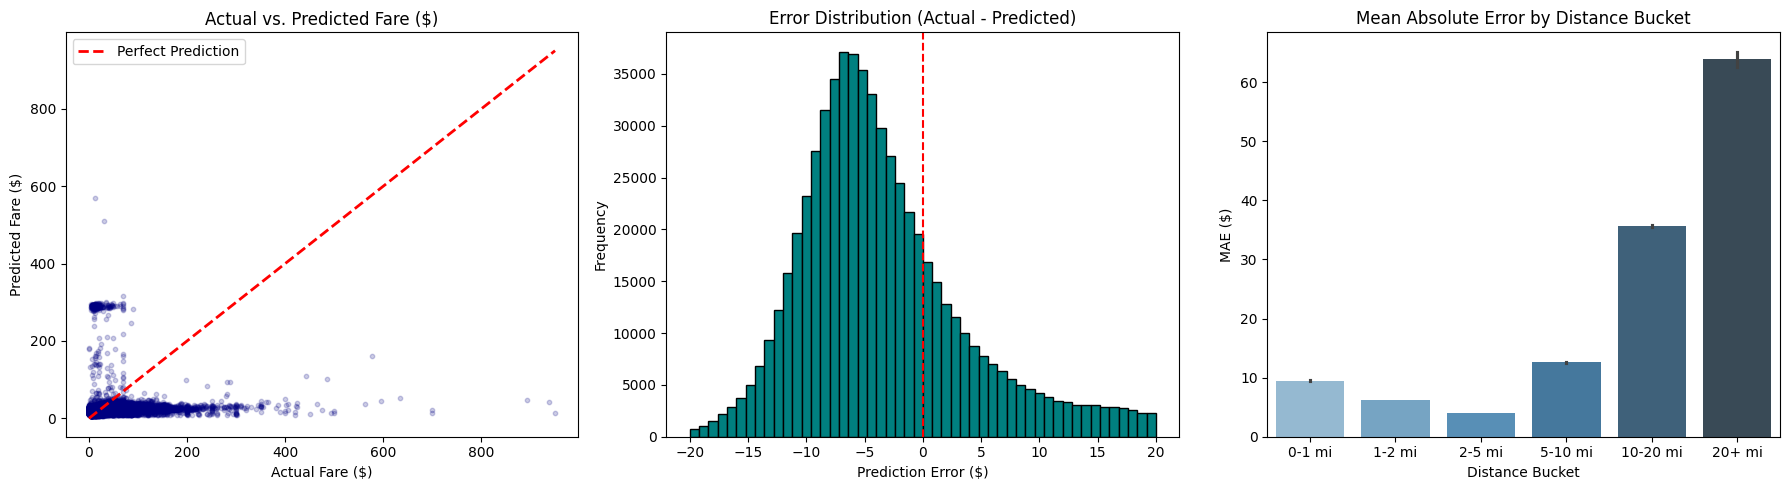

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate Residuals
residuals = y_test - y_pred_lr

# 1. Actual vs Predicted Chart
axes[0].scatter(y_test, y_pred_lr, alpha=0.2, color='navy', s=10)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    lw=2,
    label='Perfect Prediction',
)
axes[0].set_title('Actual vs. Predicted Fare ($)')
axes[0].set_xlabel('Actual Fare ($)')
axes[0].set_ylabel('Predicted Fare ($)')
axes[0].legend()

# 2. Error Distribution (Residuals)
axes[1].hist(residuals, bins=50, color='teal', edgecolor='black', range=(-20, 20))
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Error Distribution (Actual - Predicted)')
axes[1].set_xlabel('Prediction Error ($)')
axes[1].set_ylabel('Frequency')

# 3. Error by Distance Bucket
test_eval = pd.DataFrame(
    {'trip_distance': X_test['trip_distance'], 'abs_error': np.abs(residuals)}
)

distance_bins = [0, 1, 2, 5, 10, 20, np.inf]
distance_labels = ['0-1 mi', '1-2 mi', '2-5 mi', '5-10 mi', '10-20 mi', '20+ mi']
test_eval['dist_bucket'] = pd.cut(
    test_eval['trip_distance'], bins=distance_bins, labels=distance_labels
)

sns.barplot(
    data=test_eval,
    x='dist_bucket',
    y='abs_error',
    hue='dist_bucket',
    legend=False,
    palette='Blues_d',
)
axes[2].set_title('Mean Absolute Error by Distance Bucket')
axes[2].set_xlabel('Distance Bucket')
axes[2].set_ylabel('MAE ($)')

plt.tight_layout()
plt.show()